# 03 · Feature Engineering

**Phase 3 (leakage-safe preprocessing) + Phase 4 (temporal features) + Phase 5 (engine-grouped split) of the project plan.**

This is the most leakage-sensitive notebook in the pipeline. The rule enforced everywhere below: **fit every transform (sensor-selection decision, scaler, KMeans, PCA) on training engines only**, then apply it unchanged to validation and test engines. We split engines into train/validation *before* fitting anything.

Output: processed, model-ready feature tables saved to `data/processed/`, plus the fitted scaler/PCA/KMeans objects saved to `artifacts/` so notebook 06 (and any future serving code) can reuse them exactly.


In [1]:
import sys
sys.path.insert(0, "..")

import os
import joblib
import numpy as np
import pandas as pd

from src import data_loader as dl
from src import preprocessing as pp
from src import feature_engineering as fe

INTERIM_DIR = "../data/interim"
PROCESSED_DIR = "../data/processed"
ARTIFACTS_DIR = "../artifacts"
SUBSET = "FD001"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(f"{ARTIFACTS_DIR}/scalers", exist_ok=True)

train_all = pd.read_parquet(f"{INTERIM_DIR}/train_{SUBSET}_with_rul.parquet")
test_all = pd.read_parquet(f"{INTERIM_DIR}/test_{SUBSET}_with_rul.parquet")
train_all.shape, test_all.shape


((20631, 27), (13096, 27))

## Step 5 — Engine-grouped train/validation split (done first, on purpose)

Splitting *before* any fitting is what makes every downstream step leakage-safe: the validation engines are never seen by the scaler, the sensor-selection decision, the KMeans clusters, or the PCA health indicator. The official C-MAPSS test set (with `RUL_FD001.txt`) stays completely untouched as the final held-out evaluation set.


In [2]:
train_split, val_split = pp.group_train_val_split(train_all, val_size=0.2, random_state=42)
# NOTE: test_all is a separate file whose unit_number values independently restart at 1 --
# they are a different ID space, not the same engines, so it is not part of this overlap check.
pp.assert_no_engine_overlap(train_split, val_split)

print(f"train engines: {train_split['unit_number'].nunique()}  ({len(train_split)} rows)")
print(f"val engines  : {val_split['unit_number'].nunique()}  ({len(val_split)} rows)")
print(f"test engines : {test_all['unit_number'].nunique()}  ({len(test_all)} rows)  (separate file/ID space)")


train engines: 80  (16561 rows)
val engines  : 20  (4070 rows)
test engines : 100  (13096 rows)  (separate file/ID space)


## Sensor selection

Using the variance triage from `02_eda.ipynb`, recomputed here on the **train split only**. We drop `constant` sensors (zero information, by definition unaffected by anything) and keep `near_constant` + `variable` sensors as candidate features — the near-constant ones are kept because "near constant across the whole training set" does not rule out a small, real, degradation-relevant drift for an individual engine, and tree/PCA methods handle a handful of low-variance columns without material cost. This choice is explicit and revisitable.


In [3]:
variance_report = pp.classify_sensor_variance(train_split, dl.SENSOR_COLS)
constant_sensors = variance_report[variance_report["category"] == "constant"].index.tolist()
feature_sensors = variance_report[variance_report["category"] != "constant"].index.tolist()

print("Dropping (constant):", constant_sensors)
print(f"Keeping {len(feature_sensors)} sensors as features:", feature_sensors)


Dropping (constant): ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Keeping 15 sensors as features: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## Leakage-safe scaling

Fit `StandardScaler` on `train_split` only; apply the same fitted scaler to `val_split` and `test_all`.


In [4]:
scaler = pp.fit_scaler(train_split, feature_sensors)

train_scaled = pp.apply_scaler(train_split, feature_sensors, scaler)
val_scaled = pp.apply_scaler(val_split, feature_sensors, scaler)
test_scaled = pp.apply_scaler(test_all, feature_sensors, scaler)

train_scaled[feature_sensors].describe().loc[["mean", "std"]]


,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
mean,-2.197573e-14,-1.421858e-14,-4.400294e-15,-3.899311e-12,-4.518024e-14,-1.117482e-12,1.123757e-14,-3.514743e-15,1.054938e-13,7.276136e-12,3.933492e-15,-4.222154e-14,-1.643417e-14,-7.870416e-15,2.571186e-14
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00


Save this scaled-but-not-yet-lagged table separately (`*_scaled_base`) — `06_lstm_gru.ipynb` builds raw sensor sequences from this version rather than the heavily lag/rolling-engineered tabular version below, since recurrent models learn temporal patterns themselves.


In [5]:
train_scaled.to_parquet(f"{INTERIM_DIR}/train_{SUBSET}_scaled_base.parquet")
val_scaled.to_parquet(f"{INTERIM_DIR}/val_{SUBSET}_scaled_base.parquet")
test_scaled.to_parquet(f"{INTERIM_DIR}/test_{SUBSET}_scaled_base.parquet")
print("saved *_scaled_base parquet files")


saved *_scaled_base parquet files


## Temporal features: lag, rolling, diff, EMA

All grouped by `unit_number` inside `src/feature_engineering.py`, so nothing crosses an engine boundary. Window/lag sizes below are a reasonable starting point (short lags 1-3 cycles, rolling windows 5/10/20 cycles, EMA spans 5/10) — treat them as hyperparameters to revisit once you see model performance in `04_baseline_models.ipynb` / `05_tree_models.ipynb`.


In [6]:
LAGS = [1, 2, 3]
ROLLING_WINDOWS = [5, 10, 20]
EMA_SPANS = [5, 10]

def add_temporal_features(df):
    out = fe.add_lag_features(df, feature_sensors, lags=LAGS)
    out = fe.add_rolling_features(out, feature_sensors, windows=ROLLING_WINDOWS)
    out = fe.add_diff_features(out, feature_sensors, periods=[1])
    out = fe.add_ema_features(out, feature_sensors, spans=EMA_SPANS)
    return out

train_fe = add_temporal_features(train_scaled)
val_fe = add_temporal_features(val_scaled)
test_fe = add_temporal_features(test_scaled)

print(train_fe.shape, val_fe.shape, test_fe.shape)
train_fe.filter(like="sensor_11").head()


C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\

C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\

C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\

C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\

C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\src\feature_engineering.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_{stat}_{window}"] = roll.agg(stat).reset_index(level=0, drop=True)
C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\notebooks\..\

(16561, 297) (4070, 297) (13096, 297)


,sensor_11,sensor_11_lag1,sensor_11_lag2,sensor_11_lag3,sensor_11_mean_5,sensor_11_std_5,sensor_11_min_5,sensor_11_max_5,sensor_11_mean_10,sensor_11_std_10,sensor_11_min_10,sensor_11_max_10,sensor_11_mean_20,sensor_11_std_20,sensor_11_min_20,sensor_11_max_20,sensor_11_diff1,sensor_11_ema5,sensor_11_ema10
192,-2.294365,NaN,NaN,NaN,-2.294365,NaN,-2.294365,-2.294365,-2.294365,NaN,-2.294365,-2.294365,-2.294365,NaN,-2.294365,-2.294365,NaN,-2.294365,-2.294365
193,-1.127747,-2.294365,NaN,NaN,-1.711056,0.824923,-2.294365,-1.127747,-1.711056,0.824923,-2.294365,-1.127747,-1.711056,0.824923,-2.294365,-1.127747,1.166618,-1.905492,-2.082252
194,-1.203012,-1.127747,-2.294365,NaN,-1.541708,0.652905,-2.294365,-1.127747,-1.541708,0.652905,-2.294365,-1.127747,-1.541708,0.652905,-2.294365,-1.127747,-0.075266,-1.671332,-1.922390
195,-1.654606,-1.203012,-1.127747,-2.294365,-1.569932,0.536075,-2.294365,-1.127747,-1.569932,0.536075,-2.294365,-1.127747,-1.569932,0.536075,-2.294365,-1.127747,-0.451594,-1.665757,-1.873702
196,-1.090114,-1.654606,-1.203012,-1.127747,-1.473969,0.511447,-2.294365,-1.090114,-1.473969,0.511447,-2.294365,-1.090114,-1.473969,0.511447,-2.294365,-1.090114,0.564493,-1.473876,-1.731232


## Handling the NaNs introduced by lags/diffs

`lag3` and `diff1` are undefined for an engine's first few cycles. Rolling features use `min_periods=1` so they never produce NaN. We drop the (few) affected leading rows per engine — cheap here since every engine has well over 3 cycles of history, and it keeps every downstream model trained/evaluated on fully-defined feature rows. Because we drop from the *start* of each engine, the final (most-recent) row of every test engine is always preserved, which is what `RUL_FD001.txt` evaluates against.


In [7]:
lag_check_cols = [f"{feature_sensors[0]}_lag{max(LAGS)}"]
before = len(train_fe)
train_fe = train_fe.dropna(subset=lag_check_cols).reset_index(drop=True)
val_fe = val_fe.dropna(subset=lag_check_cols).reset_index(drop=True)
test_fe = test_fe.dropna(subset=lag_check_cols).reset_index(drop=True)
print(f"train rows: {before} -> {len(train_fe)} (dropped {before - len(train_fe)} leading rows)")
assert train_fe.isna().sum().sum() == 0
assert val_fe.isna().sum().sum() == 0
assert test_fe.isna().sum().sum() == 0
print("no NaNs remain in any of the three tables")


train rows: 16561 -> 16321 (dropped 240 leading rows)
no NaNs remain in any of the three tables


## Operating-condition clustering

KMeans on the operational settings, fit on train only. **FD001 has a single operating condition**, so `n_clusters=1` here is intentionally trivial (every row lands in cluster 0) — this section exists mainly so the exact same code path works unchanged when this notebook is re-run for FD002/FD004 (`n_clusters=6`), where it becomes an important normalization step.


In [8]:
n_clusters = dl.SUBSET_INFO[SUBSET].conditions
kmeans = fe.fit_operating_condition_kmeans(train_fe, dl.OP_SETTING_COLS, n_clusters=n_clusters, random_state=42)

train_fe = fe.add_operating_condition_cluster(train_fe, dl.OP_SETTING_COLS, kmeans)
val_fe = fe.add_operating_condition_cluster(val_fe, dl.OP_SETTING_COLS, kmeans)
test_fe = fe.add_operating_condition_cluster(test_fe, dl.OP_SETTING_COLS, kmeans)

train_fe["operating_condition_cluster"].value_counts()


operating_condition_cluster
0    16321
Name: count, dtype: int64

## Data-driven health indicator (PCA)

A 1-component PCA on the scaled sensors, fit on train only — **not** the paper's internal health index (that used normalized operational margins never released to challenge participants). We orient the sign so higher `health_indicator` means *more* degraded, by checking its correlation with RUL on the training split and flipping if needed.


In [9]:
health_scaler, health_pca = fe.fit_health_indicator_pca(train_fe, feature_sensors)

train_fe = fe.add_health_indicator(train_fe, feature_sensors, health_scaler, health_pca)
val_fe = fe.add_health_indicator(val_fe, feature_sensors, health_scaler, health_pca)
test_fe = fe.add_health_indicator(test_fe, feature_sensors, health_scaler, health_pca)

corr_with_rul = train_fe[["health_indicator", "RUL"]].corr().iloc[0, 1]
print(f"correlation(health_indicator, RUL) on train = {corr_with_rul:.3f}")

flip_sign = corr_with_rul < 0
if flip_sign:
    for d in (train_fe, val_fe, test_fe):
        d["health_indicator"] = -d["health_indicator"]
    print("Sign flipped: health_indicator now increases with degradation (decreases with RUL).")


correlation(health_indicator, RUL) on train = -0.730
Sign flipped: health_indicator now increases with degradation (decreases with RUL).


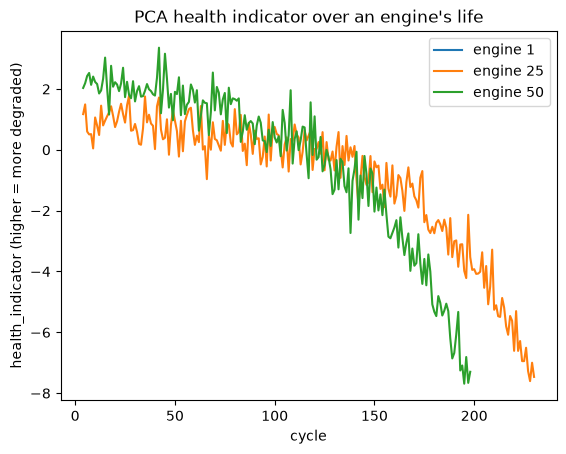

In [10]:
import matplotlib.pyplot as plt
for eng in [1, 25, 50]:
    g = train_fe[train_fe["unit_number"] == eng]
    plt.plot(g["cycle"], g["health_indicator"], label=f"engine {eng}")
plt.xlabel("cycle")
plt.ylabel("health_indicator (higher = more degraded)")
plt.title("PCA health indicator over an engine's life")
plt.legend()
plt.show()


## RUL capping (Phase 8 modeling assumption)

Early in an engine's life, sensors carry almost no information about exactly *how* healthy it is (RUL of 300 vs 320 cycles looks the same in the data) — many published C-MAPSS baselines cap the training target (commonly at 125 cycles) so the model isn't penalized for failing to distinguish RUL values that aren't distinguishable from the sensors anyway. We add a capped column alongside the raw one and let `04_baseline_models.ipynb` compare both empirically rather than assuming the cap helps.


In [11]:
RUL_CAP = 125
train_fe["RUL_capped"] = pp.cap_rul(train_fe["RUL"], cap=RUL_CAP)
val_fe["RUL_capped"] = pp.cap_rul(val_fe["RUL"], cap=RUL_CAP)
# test RUL is left uncapped -- it is the ground truth we score against, not a training target.

train_fe[["RUL", "RUL_capped"]].describe()


,RUL,RUL_capped
count,16321.000000,16321.000000
mean,106.956804,86.399424
std,68.912768,41.709515
min,0.000000,0.000000
25%,51.000000,51.000000
50%,102.000000,102.000000
75%,154.000000,125.000000
max,358.000000,125.000000


## Save processed feature tables + artifacts

Final tabular tables (`data/processed/`) will be the input to `04_baseline_models.ipynb` and `05_tree_models.ipynb`. The fitted scaler / KMeans / PCA + the exact feature-column lists are persisted to `artifacts/` so every later notebook (and eventually a serving layer) reuses identical transforms.


In [12]:
engineered_cols = [c for c in train_fe.columns if any(c.startswith(f"{s}_") for s in feature_sensors)]
feature_cols = feature_sensors + engineered_cols + dl.OP_SETTING_COLS + ["operating_condition_cluster", "health_indicator"]
print(f"{len(feature_cols)} feature columns")

train_fe.to_parquet(f"{PROCESSED_DIR}/train_{SUBSET}_features.parquet")
val_fe.to_parquet(f"{PROCESSED_DIR}/val_{SUBSET}_features.parquet")
test_fe.to_parquet(f"{PROCESSED_DIR}/test_{SUBSET}_features.parquet")

joblib.dump(scaler, f"{ARTIFACTS_DIR}/scalers/sensor_scaler_{SUBSET}.joblib")
joblib.dump(kmeans, f"{ARTIFACTS_DIR}/scalers/operating_condition_kmeans_{SUBSET}.joblib")
joblib.dump({"scaler": health_scaler, "pca": health_pca, "sign_flipped": flip_sign}, f"{ARTIFACTS_DIR}/scalers/health_indicator_pca_{SUBSET}.joblib")
joblib.dump(
    {"feature_sensors": feature_sensors, "engineered_cols": engineered_cols, "feature_cols": feature_cols, "rul_cap": RUL_CAP},
    f"{ARTIFACTS_DIR}/scalers/feature_manifest_{SUBSET}.joblib",
)
print("saved processed parquet files + artifacts")


290 feature columns


saved processed parquet files + artifacts


## Summary

- Split train engines into train/validation with `GroupShuffleSplit` on `unit_number`; verified zero engine overlap between train and validation (the test file is a separate ID space, not compared the same way).
- Selected feature sensors on the train split only (dropped `constant` sensors), fit a `StandardScaler` on train only, applied it unchanged to val/test.
- Built lag(1,2,3) / rolling(5,10,20: mean,std,min,max) / diff(1) / EMA(5,10) features per sensor, grouped by engine.
- Dropped the small number of leading NaN rows per engine created by lags/diffs.
- Fit operating-condition KMeans (trivial for FD001, meaningful for FD002/FD004) and a 1-component PCA health indicator on train only; oriented the indicator's sign against RUL.
- Added a capped-RUL training target (125 cycles) alongside the raw target, to be compared empirically.
- Saved processed feature tables to `data/processed/` and every fitted transform + feature-column manifest to `artifacts/`.

**Next:** `04_baseline_models.ipynb` — constant/linear/tree baselines, evaluated with `src/evaluate.py`, plus the raw-vs-capped RUL comparison.
